<a href="https://colab.research.google.com/github/valanchick/Spam-Classifier/blob/main/Spam_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

url = 'https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv'
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'text'])

df['label'] = df['label'].map({'ham': 0, 'spam': 1})
print(f"Размер данных: {df.shape[0]} сообщений.")

Размер данных: 5572 сообщений.


In [ ]:
import numpy as np
import pandas as pd
import re

class CustomTFIDF:
    def __init__(self):
        self.vocab = {}
        self.idf = {}
        self.vocab_size = 0
    def _clean_text(self, text):
        text = str(text).lower()
        text = re.sub(r'[^a-zа-я\s]','',text)
        return text.split()
    def fit(self, corpus):
      doc_count=len(corpus)
      word_doc_freq= {}
      for text in corpus:
          words = set(self._clean_text(text))
          for word in words:
              word_doc_freq[word] = word_doc_freq.get(word, 0)+1
      for word, freq in word_doc_freq.items():
          if freq>1:
              self.vocab[word] = self.vocab_size
              self.vocab_size+=1
              self.idf[word] = np.log((1+doc_count)/(1+freq))+1
    def transform(self, corpus):
        X = np.zeros((len(corpus), self.vocab_size), dtype=np.float64)
        for i, text in enumerate(corpus):
            words = self._clean_text(text)
            word_counts = {}
            for word in words:
                word_counts[word] = word_counts.get(word, 0)+1
            for word, count in word_counts.items():
                if word in self.vocab:
                    col_idx = self.vocab[word]
                    tf = count/len(words)
                    X[i, col_idx] = tf*self.idf[word]
        norms = np.linalg.norm(X, axis=1, keepdims=True)
        norms[norms==0]=1
        X = X/norms
        return X


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class CustomLogisticRegression:
  def __init__(self, learning_rate=0.5, n_iterations=1000):
      self.learning_rate = learning_rate
      self.n_iterations=n_iterations
      self.weights=None
      self.bias = None
      self.losses = []

  def _sigmoid(self, z):
      z = np.clip(z, -250, 250)
      return 1/(1+np.exp(-z))

  def fit(self, X, y):
      n_samples, n_features = X.shape
      self.weights = np.zeros(n_features)
      self.bias =0

      for i in range(self.n_iterations):
          linear_model = np.dot(X, self.weights)+self.bias
          y_pred = self._sigmoid(linear_model)

          dw = (1/n_samples)*np.dot(X.T, (y_pred-y))
          db = (1/n_samples)*np.sum(y_pred-y)

          self.weights-=self.learning_rate*dw
          self.bias-=self.learning_rate*db

          if i%100==0 or i==self.n_iterations-1:
              epsilon = 1e-9
              loss = -(1/n_samples)*np.sum(y*np.log(y_pred+epsilon)+(1-y)*np.log(1-y_pred+epsilon))
              self.losses.append(loss)
              if i%200==0:
                  print(f"Эпоха {i:4d} | Ошибка (Log-Loss): {loss:.4f}")
  def predict_proba(self, X):
      linear_model = np.dot(X, self.weights)+self.bias
      return self._sigmoid(linear_model)

  def predict(self, X, threshold=0.5):
      y_pred_proba = self.predict_proba(X)
      return (y_pred_proba>=threshold).astype(int)


Эпоха    0 | Ошибка (Log-Loss): 0.6931
Эпоха  200 | Ошибка (Log-Loss): 0.2760
Эпоха  400 | Ошибка (Log-Loss): 0.2124
Эпоха  600 | Ошибка (Log-Loss): 0.1760
Эпоха  800 | Ошибка (Log-Loss): 0.1527


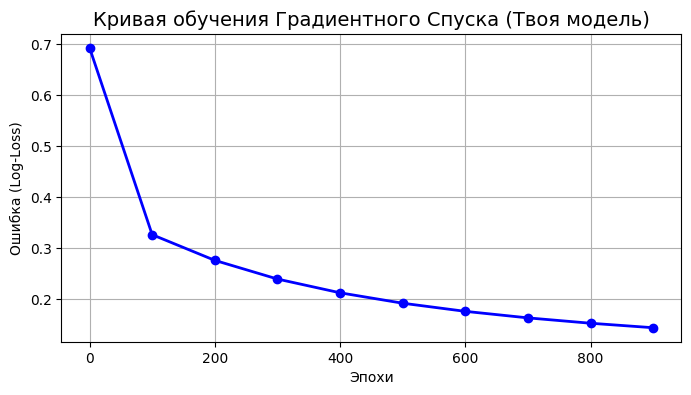

In [ ]:
from sklearn.model_selection import train_test_split

tfidf = CustomTFIDF()
tfidf.fit(df['text'])

X_features = tfidf.transform(df['text'])
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(X_features, y, test_size=0.2, random_state=42)

model = CustomLogisticRegression(learning_rate=1.5, n_iterations=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

plt.figure(figsize=(8, 4))
plt.plot(range(0, 1000, 100), model.losses[:-1], marker='o', color='b', linewidth=2)
plt.title('Кривая обучения Градиентного Спуска (Твоя модель)', fontsize=14)
plt.xlabel('Эпохи')
plt.ylabel('Ошибка (Log-Loss)')
plt.grid(True)
plt.show()

In [ ]:
def evaluate_metrics(y_true, y_pred):
    TP = np.sum((y_true==1) & (y_pred==1))
    FP = np.sum((y_true==0) & (y_pred==1))
    TN = np.sum((y_true==0) & (y_pred==0))
    FN = np.sum((y_true==1) & (y_pred==0))

    accuracy = (TP+TN)/len(y_true)
    precision = TP/(TP+FP) if TP+FP>0 else 0
    recall = TP/(TP+FN) if TP+FN>0 else 0
    f1 = 2*precision*recall/(precision+recall) if precision+recall>0 else 0

    print(f"Accuracy (Точность в целом):       {accuracy * 100:.2f}%")
    print(f"Precision (Точность спам-фильтра): {precision * 100:.2f}%")
    print(f"Recall (Полнота отлова спама):     {recall * 100:.2f}%")
    print(f"F1-Score (Гармоническое среднее):  {f1 * 100:.2f}%")
    print(f"Детализация: Отловили спама (TP) = {TP}")
    print(f"Случайно забанили хороших (FP) = {FP}")
    print(f"Пропустили спама (FN) = {FN}")

evaluate_metrics(y_test, y_pred)

Accuracy (Точность в целом):       96.05%
Precision (Точность спам-фильтра): 99.07%
Recall (Полнота отлова спама):     71.14%
F1-Score (Гармоническое среднее):  82.81%
Детализация: Отловили спама (TP) = 106
Случайно забанили хороших (FP) = 1
Пропустили спама (FN) = 43
